# Generation Length Distribution Prediction
Predict the **distribution** of token generation lengths from prompt embeddings.  
Each sample has 128 rollouts → empirical length histogram → soft probability target.  
Models: XGBoost (multi-output), MLP (PyTorch, softmax head).  
Metrics: Wasserstein distance (primary), Jensen-Shannon divergence (secondary).

In [14]:
# ── Cell 0: Config ────────────────────────────────────────────────────────────
# Identical paths / split as length_regression_pred.ipynb

import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../../"))
ROLLOUT_DIR  = os.path.join(PROJECT_ROOT, "rollouts")
EMBED_DIR    = os.path.join(PROJECT_ROOT, "len_pred", "preprocess", "output")

JSONL_NAME   = "inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl"
EMBED_NAME   = "inference_qwen3-4b_math500_G4_B32768_chunk0__Qwen3-Embedding-4B.parquet"

JSONL_PATH   = f"{ROLLOUT_DIR}/{JSONL_NAME}"
EMBED_PATH   = f"{EMBED_DIR}/{EMBED_NAME}"

# Binning: log-spaced over the observed range.
# 12 bins gives ~10 rollouts/bin on average (128 rollouts / 12 bins).
N_BINS       = 12
BIN_MIN      = 500     # slightly below observed min (~593)
BIN_MAX      = 33000   # slightly above observed max (~32721)

# !! Keep these identical to length_regression_pred.ipynb for a fair comparison !!
SEED         = 42
TEST_SIZE    = 0.2

# MLP trainingz
MLP_EPOCHS      = 300
MLP_BATCH_SIZE  = 32
MLP_LR          = 1e-3

In [16]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance
from scipy.special import rel_entr          # for KL / JS
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor

import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Fix seeds globally (same as length_regression_pred.ipynb)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [17]:
# ── Cell 1: Define log-spaced bins ────────────────────────────────────────────
bin_edges = np.logspace(np.log10(BIN_MIN), np.log10(BIN_MAX), N_BINS + 1)
# Bin centers (in log space) — used as "positions" for Wasserstein distance
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

print(f"Bin edges (rounded):")
print(np.round(bin_edges).astype(int).tolist())
print(f"\nBin centers (rounded):")
print(np.round(bin_centers).astype(int).tolist())

Bin edges (rounded):
[500, 709, 1005, 1425, 2021, 2865, 4062, 5759, 8166, 11578, 16416, 23275, 33000]

Bin centers (rounded):
[595, 844, 1197, 1697, 2406, 3411, 4837, 6858, 9723, 13786, 19547, 27714]


In [18]:
# ── Cell 2: Build soft label distributions from rollout JSONL ──────────────────
# For each sample_idx, collect all rollout token lengths → empirical histogram → 
# normalize to probability distribution (soft label).

rollout_lengths = defaultdict(list)  # sample_idx -> [token_len, ...]

with open(JSONL_PATH) as f:
    for line in f:
        d = json.loads(line)
        sid = d["sample_idx"]
        for output in d["method_output"]["outputs"]:
            rollout_lengths[sid].append(len(output["token_ids"]))

sample_ids = sorted(rollout_lengths.keys())
n_rollouts_per_sample = len(rollout_lengths[sample_ids[0]])
print(f"Samples: {len(sample_ids)}  |  Rollouts/sample: {n_rollouts_per_sample}")

# Build probability matrix: shape (n_samples, N_BINS)
prob_matrix = np.zeros((len(sample_ids), N_BINS), dtype=np.float32)
for i, sid in enumerate(sample_ids):
    lengths = np.array(rollout_lengths[sid])
    counts, _ = np.histogram(lengths, bins=bin_edges)
    prob_matrix[i] = counts / counts.sum()   # normalize to probability

labels_df = pd.DataFrame(
    prob_matrix,
    columns=[f"bin_{j}" for j in range(N_BINS)]
)
labels_df.insert(0, "sample_idx", sample_ids)

print(f"Label shape: {prob_matrix.shape}  (rows=samples, cols=bins)")
print(f"Row-sum sanity check (should all be 1.0): min={prob_matrix.sum(axis=1).min():.4f}  max={prob_matrix.sum(axis=1).max():.4f}")

Samples: 500  |  Rollouts/sample: 128
Label shape: (500, 12)  (rows=samples, cols=bins)
Row-sum sanity check (should all be 1.0): min=1.0000  max=1.0000


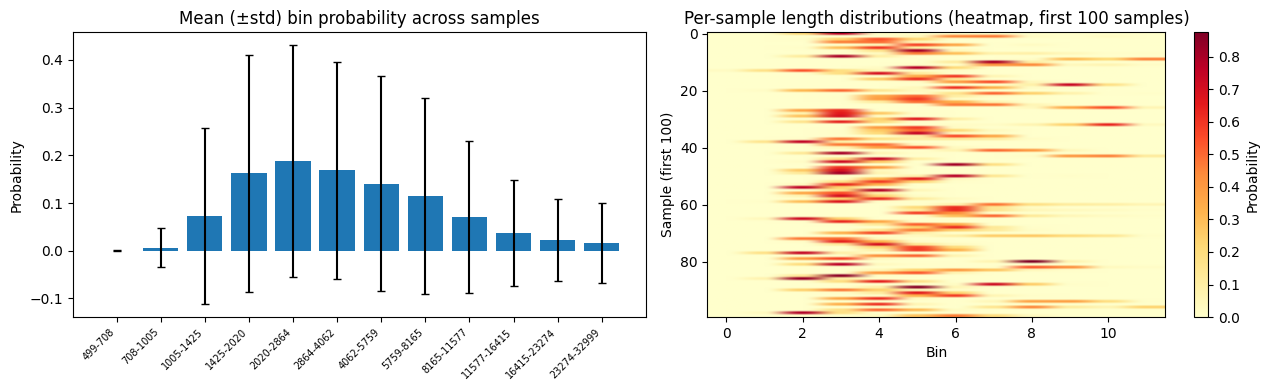

In [19]:
# ── Cell 3: Visualize aggregate distribution & per-sample spread ───────────────
mean_prob = prob_matrix.mean(axis=0)
std_prob  = prob_matrix.std(axis=0)

bin_labels = [f"{int(bin_edges[j])}-{int(bin_edges[j+1])}" for j in range(N_BINS)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Average distribution across all samples
axes[0].bar(range(N_BINS), mean_prob, yerr=std_prob, capsize=3)
axes[0].set_xticks(range(N_BINS))
axes[0].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("Probability")
axes[0].set_title("Mean (±std) bin probability across samples")

# Heatmap: each row = one sample's length distribution
im = axes[1].imshow(prob_matrix[:100], aspect="auto", cmap="YlOrRd")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Sample (first 100)")
axes[1].set_title("Per-sample length distributions (heatmap, first 100 samples)")
plt.colorbar(im, ax=axes[1], label="Probability")

plt.tight_layout()
plt.show()

In [20]:
# ── Cell 4: Load embeddings ────────────────────────────────────────────────────
embed_df = pd.read_parquet(EMBED_PATH)
dim_cols = [c for c in embed_df.columns if c != "sample_idx"]
print(f"Embeddings: {len(embed_df)} samples  |  dim: {len(dim_cols)}")

Embeddings: 500 samples  |  dim: 2560


In [21]:
# ── Cell 5: Merge & train/test split ──────────────────────────────────────────
# Same SEED and TEST_SIZE as length_regression_pred.ipynb → same sample split.

bin_cols = [f"bin_{j}" for j in range(N_BINS)]
df = embed_df.merge(labels_df, on="sample_idx", how="inner")
print(f"Merged shape: {df.shape}")

X = df[dim_cols].values.astype(np.float32)
Y = df[bin_cols].values.astype(np.float32)  # shape (n_samples, N_BINS)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=SEED
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Merged shape: (500, 2573)
Train: 400  |  Test: 100


In [22]:
# ── Cell 6: Metrics ────────────────────────────────────────────────────────────
# Wasserstein distance: accounts for ordinal bin structure (distance between
#   bins matters). Best metric when bins are ordered and unequally spaced.
# Jensen-Shannon divergence: symmetric, bounded [0, ln2], always defined
#   (unlike KL which is undefined when predicted prob = 0).

results = {}

def js_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-10) -> float:
    """Jensen-Shannon divergence for two probability vectors."""
    m = 0.5 * (p + q) + eps
    return float(0.5 * np.sum(rel_entr(p + eps, m)) + 0.5 * np.sum(rel_entr(q + eps, m)))


def evaluate(name: str, Y_true: np.ndarray, Y_pred_raw: np.ndarray) -> dict:
    """Softmax-normalize predictions then compute per-sample metrics."""
    # Ensure valid probability distributions
    Y_pred = np.exp(Y_pred_raw - Y_pred_raw.max(axis=1, keepdims=True))
    Y_pred = Y_pred / Y_pred.sum(axis=1, keepdims=True)

    ws_distances, js_divs = [], []
    for p_true, p_pred in zip(Y_true, Y_pred):
        ws_distances.append(wasserstein_distance(bin_centers, bin_centers, p_true, p_pred))
        js_divs.append(js_divergence(p_true, p_pred))

    ws  = float(np.mean(ws_distances))
    jsd = float(np.mean(js_divs))
    print(f"{name:20s}  Wasserstein={ws:8.1f}  JSD={jsd:.4f}")
    results[name] = {"Wasserstein": ws, "JSD": jsd, "Y_pred": Y_pred}
    return results[name]

In [23]:
# ── Cell 7: Baseline — predict mean distribution ───────────────────────────────
# A sensible baseline: predict the training-set mean distribution for every sample.
mean_dist = Y_train.mean(axis=0, keepdims=True)   # shape (1, N_BINS)
Y_pred_baseline = np.repeat(mean_dist, len(Y_test), axis=0)
evaluate("Baseline (mean dist)", Y_test, Y_pred_baseline)

Baseline (mean dist)  Wasserstein=  5959.5  JSD=0.3934


{'Wasserstein': 5959.495331542196,
 'JSD': 0.3934178376197815,
 'Y_pred': array([[0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682],
        [0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682],
        [0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682],
        ...,
        [0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682],
        [0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682],
        [0.07651205, 0.07693613, 0.08206461, ..., 0.07919096, 0.07837544,
         0.07761682]], shape=(100, 12), dtype=float32)}

In [24]:
# ── Cell 8: Model 1 — XGBoost (multi-output) ──────────────────────────────────
# Train one XGBRegressor per bin via MultiOutputRegressor.
# Outputs are softmax-normalized in evaluate().

xgb_base = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_model = MultiOutputRegressor(xgb_base, n_jobs=1)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)  # shape (n_test, N_BINS)
evaluate("XGBoost", Y_test, Y_pred_xgb)

XGBoost               Wasserstein=  5895.2  JSD=0.3866


{'Wasserstein': 5895.181217259469,
 'JSD': 0.38658977270126343,
 'Y_pred': array([[0.0776889 , 0.07759321, 0.07891706, ..., 0.08390466, 0.07849401,
         0.07763581],
        [0.07701406, 0.07699368, 0.08032092, ..., 0.07710385, 0.07677065,
         0.07714128],
        [0.07709672, 0.0771534 , 0.08243903, ..., 0.07673395, 0.07749528,
         0.07713558],
        ...,
        [0.07616027, 0.0761461 , 0.07921132, ..., 0.07745704, 0.07711541,
         0.07704791],
        [0.07637916, 0.07609026, 0.07934059, ..., 0.0816442 , 0.07809813,
         0.07624783],
        [0.07657468, 0.07665615, 0.07914908, ..., 0.0794548 , 0.07955417,
         0.07964718]], shape=(100, 12), dtype=float32)}

  Epoch  20/300  KL=0.3602
  Epoch  40/300  KL=0.1286
  Epoch  60/300  KL=0.0798
  Epoch  80/300  KL=0.0606
  Epoch 100/300  KL=0.0547
  Epoch 120/300  KL=0.0509
  Epoch 140/300  KL=0.0419
  Epoch 160/300  KL=0.0416
  Epoch 180/300  KL=0.0351
  Epoch 200/300  KL=0.0364
  Epoch 220/300  KL=0.0304
  Epoch 240/300  KL=0.0292
  Epoch 260/300  KL=0.0287
  Epoch 280/300  KL=0.0265
  Epoch 300/300  KL=0.0252
MLP                   Wasserstein=  5754.1  JSD=0.3740


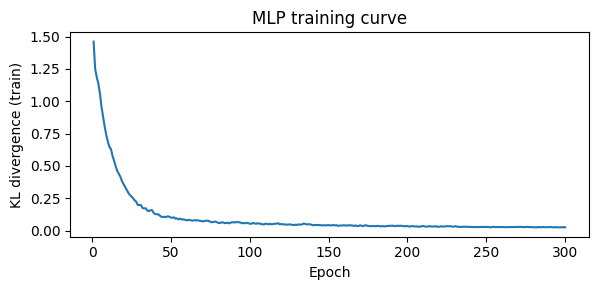

In [25]:
# ── Cell 9: Model 2 — MLP (PyTorch, softmax output) ───────────────────────────

class MLPDist(nn.Module):
    """MLP with softmax output for probability distribution prediction.
    Extend by changing hidden_dims or output_dim."""
    def __init__(self, input_dim: int, output_dim: int, hidden_dims: list = [512, 128], dropout: float = 0.2):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)


def kl_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """KL(target || pred) — trains the MLP to match the empirical distribution."""
    return (target * (target + eps).log() - target * (pred + eps).log()).sum(dim=-1).mean()


def train_mlp_dist(X_tr, Y_tr, epochs=MLP_EPOCHS, batch_size=MLP_BATCH_SIZE, lr=MLP_LR):
    torch.manual_seed(SEED)
    model = MLPDist(input_dim=X_tr.shape[1], output_dim=N_BINS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(
        torch.from_numpy(X_tr).to(DEVICE),
        torch.from_numpy(Y_tr).to(DEVICE),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_history = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = kl_loss(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        loss_history.append(epoch_loss / len(X_tr))
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  KL={loss_history[-1]:.4f}")

    return model, loss_history


mlp_model, loss_history = train_mlp_dist(X_train, Y_train)

mlp_model.eval()
with torch.no_grad():
    Y_pred_mlp = mlp_model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy()
# MLP already outputs softmax probs — pass directly (evaluate() re-normalizes but it's a no-op)
evaluate("MLP", Y_test, Y_pred_mlp)

# Loss curve
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, MLP_EPOCHS + 1), loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("KL divergence (train)")
ax.set_title("MLP training curve")
plt.tight_layout()
plt.show()

In [ ]:
# ── Retrieval-based prediction ───────────────────────────────────────
# Embeddings are L2-normalized (from embed.py) → cosine similarity = dot product.
# Strategy: for each test prompt, find top-k most similar training prompts
# and average their empirical length distributions.
#
# Why this can beat XGBoost/MLP on small data:
#   - No model fitting; directly leverages geometry of the embedding space.
#   - Soft averaging smooths out noise in individual empirical histograms.
#
# Similarity matrix: (n_test, n_train) — single matmul, ~0.1s even for dim=2560.

# Top-k values and top-p% to sweep
TOP_K_LIST = [1, 3, 5, 10, 20]
TOP_P_LIST = [0.05, 0.10]   # fraction of training set

# Compute full cosine similarity matrix in one shot (fast: pure numpy matmul)
sim_matrix = X_test @ X_train.T   # shape: (n_test, n_train)
print(f"Similarity matrix: {sim_matrix.shape}  [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")

def retrieval_predict(sim: np.ndarray, Y_tr: np.ndarray, k: int) -> np.ndarray:
    """For each test sample, average the distributions of the top-k most similar
    training samples. Weights are uniform (hard top-k)."""
    top_k_idx = np.argpartition(sim, -k, axis=1)[:, -k:]  # (n_test, k)
    # Weighted by similarity score (softmax over top-k scores)
    top_k_sims = sim[np.arange(len(sim))[:, None], top_k_idx]  # (n_test, k)
    weights = np.exp(top_k_sims - top_k_sims.max(axis=1, keepdims=True))  # softmax
    weights /= weights.sum(axis=1, keepdims=True)  # (n_test, k)
    # Weighted average of neighbor distributions
    neighbors = Y_tr[top_k_idx]  # (n_test, k, N_BINS)
    return np.einsum('nk,nkd->nd', weights, neighbors)

# Sweep top-k
for k in TOP_K_LIST:
    Y_pred_ret = retrieval_predict(sim_matrix, Y_train, k=k)
    evaluate(f"Retrieval top-{k}", Y_test, Y_pred_ret)

# Sweep top-p%
for p in TOP_P_LIST:
    k_p = max(1, int(round(p * len(X_train))))
    Y_pred_ret = retrieval_predict(sim_matrix, Y_train, k=k_p)
    evaluate(f"Retrieval top-{int(p*100)}% (k={k_p})", Y_test, Y_pred_ret)

Similarity matrix: (100, 400)  [0.161, 0.872]
Retrieval top-1       Wasserstein=  5820.6  JSD=0.3830
Retrieval top-3       Wasserstein=  5835.8  JSD=0.3830
Retrieval top-5       Wasserstein=  5841.7  JSD=0.3838
Retrieval top-10      Wasserstein=  5856.8  JSD=0.3849
Retrieval top-20      Wasserstein=  5874.7  JSD=0.3863
Retrieval top-5% (k=20)  Wasserstein=  5874.7  JSD=0.3863
Retrieval top-10% (k=40)  Wasserstein=  5886.1  JSD=0.3876


In [ ]:
# ── Comparison: metrics table (all models) ────────────────────────────────────
metrics_df = pd.DataFrame(
    {name: {k: v for k, v in vals.items() if k != "Y_pred"} for name, vals in results.items()}
).T.sort_values("Wasserstein")
print(metrics_df.to_string(float_format="{:.4f}".format))


                          Wasserstein    JSD
MLP                         5754.0925 0.3740
Retrieval top-1             5820.5720 0.3830
Retrieval top-3             5835.8400 0.3830
Retrieval top-5             5841.7025 0.3838
Retrieval top-10            5856.8194 0.3849
Retrieval top-20            5874.6649 0.3863
Retrieval top-5% (k=20)     5874.6649 0.3863
Retrieval top-10% (k=40)    5886.0731 0.3876
XGBoost                     5895.1812 0.3866
Baseline (mean dist)        5959.4953 0.3934


In [46]:
# ── Plot helper (reused by model and retrieval plot cells) ────────────────────
def _ws_per_sample(model_names):
    return {
        name: [
            wasserstein_distance(bin_centers, bin_centers, Y_test[i], results[name]["Y_pred"][i])
            for i in range(len(Y_test))
        ]
        for name in model_names
    }

def plot_comparison(model_names, sample_indices=(0, 1, 2), title_prefix=""):
    """Box plot of per-sample Wasserstein + bar chart of true vs predicted
    for a few test samples, for the given list of model names."""
    ws = _ws_per_sample(model_names)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Box plot
    axes[0].boxplot(list(ws.values()), labels=list(ws.keys()), patch_artist=True)
    axes[0].set_ylabel("Wasserstein distance")
    axes[0].set_title(f"{title_prefix} Per-sample Wasserstein (lower = better)")
    axes[0].tick_params(axis='x', rotation=30)

    # Bar chart: true vs predicted for a few samples
    x = np.arange(N_BINS)
    colors = plt.cm.tab10.colors
    si = list(sample_indices)
    n_models = len(model_names)
    bar_w = 0.7 / (n_models + 1)  # +1 for ground truth

    for j, i in enumerate(si):
        offset = j * (n_models + 2) * bar_w
        axes[1].bar(x + offset, Y_test[i], width=bar_w, alpha=0.85,
                    color="steelblue", label="True" if j == 0 else None)
        for m_idx, name in enumerate(model_names):
            axes[1].bar(x + offset + (m_idx + 1) * bar_w,
                        results[name]["Y_pred"][i], width=bar_w, alpha=0.75,
                        color=colors[(m_idx + 1) % 10],
                        label=name if j == 0 else None)

    axes[1].set_xticks([])
    axes[1].set_ylabel("Probability")
    axes[1].set_title(f"{title_prefix} True vs Predicted (test samples {si})")
    axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2644635/3038317756.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(list(ws.values()), labels=list(ws.keys()), patch_artist=True)


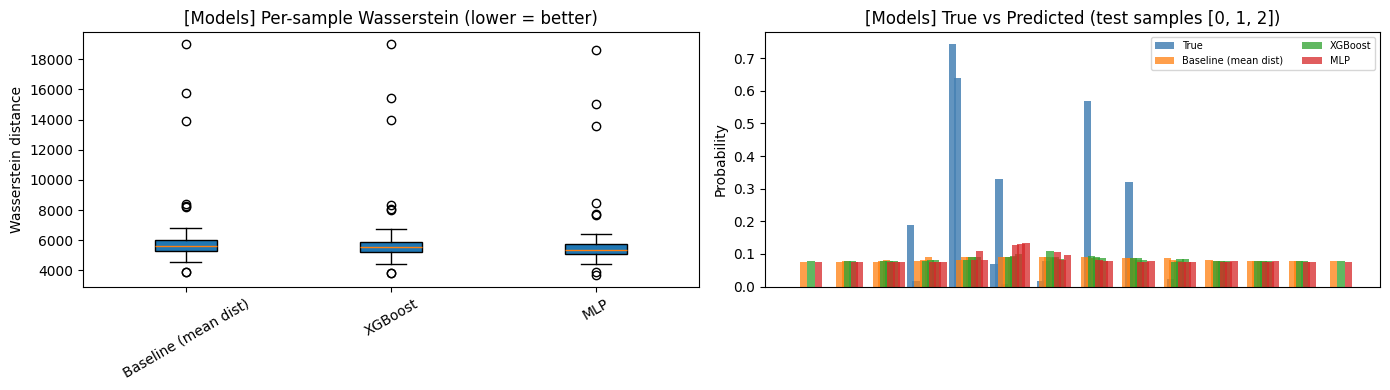

In [47]:
# ── Comparison: model-based predictions (Baseline / XGBoost / MLP) ────────────
model_names = [m for m in results if not m.startswith("Retrieval")]
plot_comparison(model_names, title_prefix="[Models]")


/tmp/ipykernel_2644635/3038317756.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(list(ws.values()), labels=list(ws.keys()), patch_artist=True)


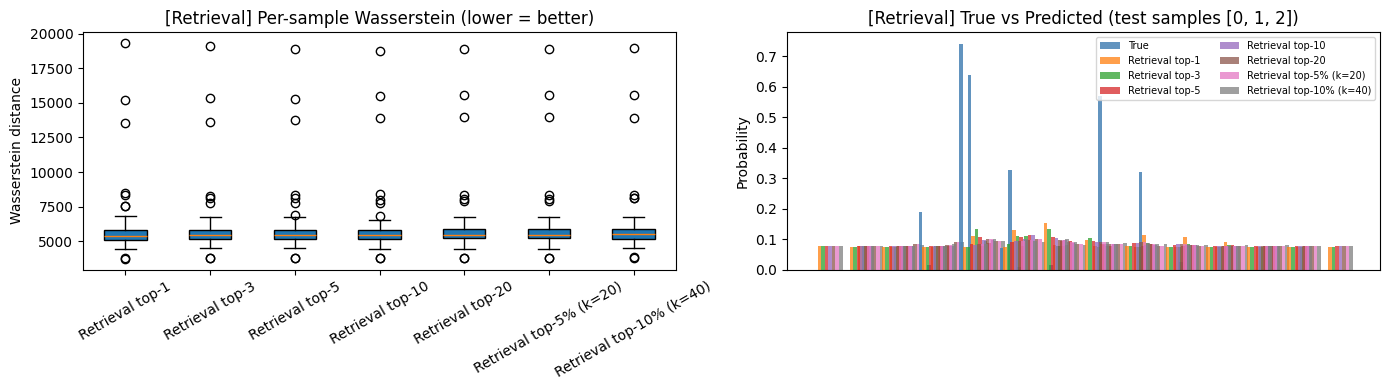

In [48]:
# ── Comparison: retrieval-based predictions ───────────────────────────────────
retrieval_names = [m for m in results if m.startswith("Retrieval")]
plot_comparison(retrieval_names, title_prefix="[Retrieval]")


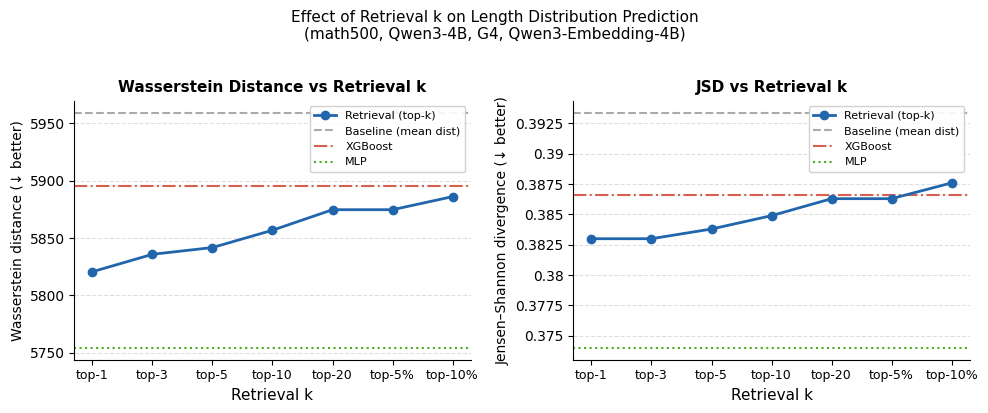

Saved retrieval_k_sweep.pdf / .png


In [1]:
# ── Retrieval k-sweep: research-ready line plot ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---- data (from retrieval cell outputs) ----
entries = [
    ("top-1",       1,    5820.6, 0.3830),
    ("top-3",       3,    5835.8, 0.3830),
    ("top-5",       5,    5841.7, 0.3838),
    ("top-10",      10,   5856.8, 0.3849),
    ("top-20",      20,   5874.7, 0.3863),
    ("top-5%",      20,   5874.7, 0.3863),
    ("top-10%",     40,   5886.1, 0.3876),
]
labels      = [e[0] for e in entries]
ks          = [e[1] for e in entries]
wasserstein = [e[2] for e in entries]
jsd         = [e[3] for e in entries]

# reference lines (all methods use the same test set)
baseline_ws  = 5959.5
baseline_jsd = 0.3934
xgb_ws       = 5895.2
xgb_jsd      = 0.3866
mlp_ws       = 5754.1
mlp_jsd      = 0.3740

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

RETRIEVAL_COLOR = "#2166ac"
BASELINE_COLOR  = "#aaaaaa"
XGB_COLOR       = "#d6604d"
MLP_COLOR       = "#4dac26"

x = np.arange(len(labels))

for ax, metric, ret_vals, bl, xgb_v, mlp_v, ylabel, title in [
    (axes[0], "Wasserstein", wasserstein, baseline_ws, xgb_ws, mlp_ws,
     "Wasserstein distance (↓ better)", "Wasserstein Distance vs Retrieval k"),
    (axes[1], "JSD",         jsd,         baseline_jsd, xgb_jsd, mlp_jsd,
     "Jensen–Shannon divergence (↓ better)", "JSD vs Retrieval k"),
]:
    ax.plot(x, ret_vals, marker="o", linewidth=2, markersize=6,
            color=RETRIEVAL_COLOR, label="Retrieval (top-k)", zorder=3)

    ax.axhline(bl,    color=BASELINE_COLOR, linewidth=1.5, linestyle="--", label="Baseline (mean dist)")
    ax.axhline(xgb_v, color=XGB_COLOR,      linewidth=1.5, linestyle="-.", label="XGBoost")
    ax.axhline(mlp_v, color=MLP_COLOR,      linewidth=1.5, linestyle=":",  label="MLP")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Retrieval k", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, framealpha=0.9)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4g"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Effect of Retrieval k on Length Distribution Prediction\n"
             "(math500, Qwen3-4B, G4, Qwen3-Embedding-4B)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("retrieval_k_sweep.pdf", bbox_inches="tight")
plt.savefig("retrieval_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved retrieval_k_sweep.pdf / .png")


In [49]:
# ── Per-sample by `sample_idx`: truth vs prediction (separate panels, no overlay) ─
# Uses the same train/test split as Cell 5 (`TEST_SIZE`, `SEED`) so the id matches
# rollout JSONL `sample_idx`, not the row index inside `Y_test`.

def _test_set_sample_idx_order():
    row_idx = np.arange(len(df))
    _, _, _, _, _, idx_test = train_test_split(
        X, Y, row_idx, test_size=TEST_SIZE, random_state=SEED
    )
    return df.iloc[idx_test]["sample_idx"].to_numpy()


def plot_length_dist_by_sample_idx(sample_idx: int, model_name: str | None = None, figsize=(12, 3.5)):
    """Bar plot of **ground truth** and **prediction** on separate axes (no overlay).

    Parameters
    ----------
    sample_idx : int
        Dataset id (`sample_idx` column / rollout JSONL field).
    model_name : str, optional
        Key in `results` (e.g. "MLP", "XGBoost"). Default: last non-baseline model.
    """
    sid_order = _test_set_sample_idx_order()
    hits = np.where(sid_order == sample_idx)[0]
    if hits.size == 0:
        raise ValueError(
            f"sample_idx={sample_idx} is not in the test split "
            f"({len(sid_order)} test samples; pick another id or inspect sid_order)."
        )
    i = int(hits[0])

    if model_name is None:
        candidates = [m for m in results if m != "Baseline (mean dist)"]
        if not candidates:
            raise ValueError("`results` is empty — run the model cells first.")
        model_name = candidates[-1]

    y_true = Y_test[i]
    y_pred = results[model_name]["Y_pred"][i]
    x = np.arange(N_BINS)
    xtlabels = [f"{int(bin_edges[j])}-" for j in range(N_BINS)]

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    axes[0].bar(x, y_true, color="steelblue", alpha=0.85)
    axes[0].set_title(f"Ground truth (sample_idx={sample_idx})")
    axes[0].set_ylabel("Probability")

    axes[1].bar(x, y_pred, color="darkorange", alpha=0.85)
    axes[1].set_title(f"Predicted — {model_name}")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(xtlabels, rotation=45, ha="right", fontsize=7)
    plt.tight_layout()
    plt.show()


# Example (use a `sample_idx` that landed in the test split):
# _sid = _test_set_sample_idx_order()
# plot_length_dist_by_sample_idx(int(_sid[0]))


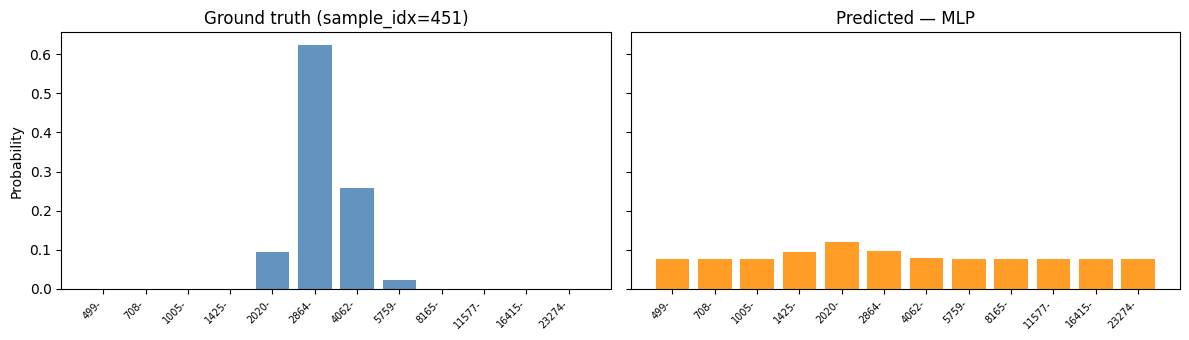

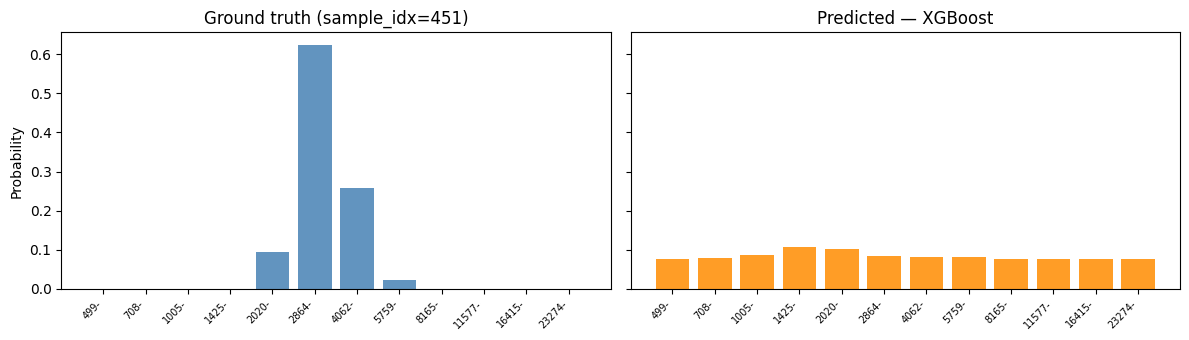

In [50]:
_sid = _test_set_sample_idx_order()
index = 66
plot_length_dist_by_sample_idx(_sid[index], "MLP")           # default model
plot_length_dist_by_sample_idx(_sid[index], "XGBoost")